In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 1. Define where your zip file is in Drive
# Hint: If you just uploaded it to the main folder, it's likely here:
zip_path = '/content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip'

# 2. Unzip into a local folder
!unzip "$zip_path" -d "/content/cumida_data"

# 3. Check the file name inside
print("Files found:", os.listdir("/content/cumida_data"))

Archive:  /content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip
  inflating: /content/cumida_data/Breast_GSE45827.csv  
Files found: ['Breast_GSE45827.csv']


In [ ]:
import pandas as pd
import glob

# Find the CSV automatically (so exact filename doesn't matter)
csv_files = glob.glob('/content/cumida_data/*.csv')

if csv_files:
    file_path = csv_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_csv(file_path)

    # Quick sanity check
    print(f"Data Shape: {df.shape}") # Should be approx (151, 54678)
    print("Classes:", df['type'].unique())
else:
    print("No CSV found! Check your zip file.")

Loading: /content/cumida_data/Breast_GSE45827.csv
Data Shape: (151, 54677)
Classes: ['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load Data (assuming you unzipped it as discussed)
# Replace with your actual path if different
df = pd.read_csv('/content/cumida_data/Breast_GSE45827.csv')

# 2. Separate Target & Features
# 'type' is usually the target in CuMiDa, 'samples' is metadata
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

# 3. Label Encoding (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes found: {le.classes_}")

# 4. Train/Test Split (Stratified is crucial for small data!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- BRANCH A: For Traditional & Transformer (Numerical) ---

# Step A1: Feature Selection (Reduce 54k -> 2k genes)
# We only fit this on TRAIN data to avoid data leakage
selector = SelectKBest(score_func=f_classif, k=10000)
selector.fit(X_train_raw, y_train)

# Get the names of the top genes (We need these for the LLM later!)
top_gene_names = X.columns[selector.get_support()]

# Transform the data
X_train_reduced = selector.transform(X_train_raw)
X_test_reduced = selector.transform(X_test_raw)

# Step A2: Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"Original Shape: {X_train_raw.shape}")
print(f"Processed Shape: {X_train_scaled.shape}")

# --- BRANCH B: For LLM (Text Serialization) ---

def serialize_row(row_values, feature_names):
    """Convert a row of gene values into a text description."""
    text_parts = []
    # We zip the gene names with their values
    for name, val in zip(feature_names, row_values):
        # We can simplify: is it positive (up-regulated) or negative?
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")

    # Join first 50 genes to keep text length manageable for BERT
    return "Breast cancer profile: " + ", ".join(text_parts[:50]) + "."

# Apply to Train data
# Note: We use the REDUCED data so we only serialize important genes
X_train_text = [serialize_row(row, top_gene_names) for row in X_train_reduced]
X_test_text = [serialize_row(row, top_gene_names) for row in X_test_reduced]

print(f"LLM Example Input: {X_train_text[0][:100]}...")

Classes found: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']
Original Shape: (120, 54675)
Processed Shape: (120, 10000)
LLM Example Input: Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is high, 1552263_at is high, 1552264...


In [ ]:
# 1. Install the Hub library
!pip install huggingface_hub

# 2. Login Widget
from huggingface_hub import notebook_login

print("👇 Paste your token in the box below and click Login")
notebook_login()

👇 Paste your token in the box below and click Login


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# 1. Regenerate Text using SCALED data (X_train_scaled) instead of raw
# This ensures values are centered at 0, so 'val > 0' actually differentiates High vs Low.

def serialize_row_corrected(row_values, feature_names):
    text_parts = []
    for name, val in zip(feature_names, row_values):
        # Now val will be negative (Low) or positive (High)
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")
    return "Breast cancer profile: " + ", ".join(text_parts[:50])

print("🔄 Regenerating text data with correct scaling...")

# IMPORTANT: We use X_train_scaled here!
X_train_text = [serialize_row_corrected(row, top_gene_names) for row in X_train_scaled]
X_test_text = [serialize_row_corrected(row, top_gene_names) for row in X_test_scaled]

# 2. Verify the Fix (Check if they look different now)
print("\n--- Patient 0 ---")
print(X_train_text[0][:150])

print("\n--- Patient 1 ---")
print(X_train_text[1][:150])

🔄 Regenerating text data with correct scaling...

--- Patient 0 ---
Breast cancer profile: 1053_at is high, 117_at is low, 1487_at is low, 1552263_at is low, 1552264_a_at is low, 1552277_a_at is low, 1552288_at is high

--- Patient 1 ---
Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is low, 1552263_at is low, 1552264_a_at is low, 1552277_a_at is low, 1552288_at is hig


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# --- 1. CONFIGURATION ---
MODEL_NAME = "distilbert-base-uncased"
AUGMENT_FACTOR = 5   # Reduced slightly for speed, but high quality
TOP_N_GENES = 50     # We will find the 50 *best* genes, not just the loudest

# --- 2. INTELLIGENT FEATURE SELECTION (The Fix) ---
print("🔍 Running ANOVA to find the 50 most distinctive genes...")

# We use the SCALED data (X_train_scaled) and labels (y_train)
# This finds genes that vary significantly between Basal, Luminal, etc.
selector = SelectKBest(score_func=f_classif, k=TOP_N_GENES)
selector.fit(X_train_scaled, y_train)

# Get the indices of these 50 "Star" genes
best_gene_indices = selector.get_support(indices=True)

# Recover their names (Handling the case where column names might be lost)
if 'X' in locals():
    all_feature_names = X.columns
else:
    # Fallback if you restarted the runtime
    all_feature_names = np.array([f"Gene_{i}" for i in range(X_train_scaled.shape[1])])

best_gene_names = all_feature_names[best_gene_indices]

print(f"✅ Selected Top Genes: {best_gene_names[:5]}... (These differentiate the cancers)")

# --- 3. SERIALIZATION USING ONLY BEST GENES ---
def serialize_discriminative(row_values, best_indices, best_names):
    text_parts = []

    # Only look at the 50 best indices we found
    for idx, name in zip(best_indices, best_names):
        val = row_values[idx]

        # Describe: Since data is scaled, 0 is the mean.
        if val > 1.5: status = "strongly upregulated"
        elif val > 0.5: status = "upregulated"
        elif val < -1.5: status = "strongly downregulated"
        elif val < -0.5: status = "downregulated"
        else: status = "normal" # Skip "normal" to save tokens? No, keep for context.

        # Only include if it's NOT normal (High signal to noise)
        if status != "normal":
            text_parts.append(f"{name} is {status}")

    if not text_parts:
        return "Breast cancer genetic profile: No significant anomalies."

    return "Breast cancer genetic profile: " + ", ".join(text_parts) + "."

# Apply to Train
X_train_text_aug = []
y_train_aug = []

print("🔄 Generating Text with Distinctive Genes...")
for row, label in zip(X_train_scaled, y_train):
    # Base text
    base_text = serialize_discriminative(row, best_gene_indices, best_gene_names)
    X_train_text_aug.append(base_text)
    y_train_aug.append(label)

    # Augmentation: Shuffle the list to create variations
    # We strip the prefix/suffix, shuffle, and rebuild
    content = base_text.replace("Breast cancer genetic profile: ", "").replace(".", "")
    genes = content.split(", ")

    for _ in range(AUGMENT_FACTOR):
        np.random.shuffle(genes)
        aug_text = "Breast cancer genetic profile: " + ", ".join(genes) + "."
        X_train_text_aug.append(aug_text)
        y_train_aug.append(label)

# Apply to Test (No Augmentation)
X_test_text = [serialize_discriminative(row, best_gene_indices, best_gene_names) for row in X_test_scaled]

# Check meaningful difference
print(f"Sample Patient A: {X_train_text_aug[0][:100]}...")
print(f"Sample Patient B: {X_train_text_aug[AUGMENT_FACTOR+1][:100]}...")

# --- 4. DATASET & TOKENIZER ---
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class GeneTextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=512)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = GeneTextDataset(X_train_text_aug, y_train_aug, tokenizer)
test_dataset = GeneTextDataset(X_test_text, y_test, tokenizer)

# --- 5. MODEL & WEIGHTED TRAINER ---
model_llm = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)
model_llm.to('cuda' if torch.cuda.is_available() else 'cpu')

# Calculate weights
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(model_llm.device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results_smart_select',
    num_train_epochs=15,
    learning_rate=5e-5,              # Slightly aggressive to escape local min
    per_device_train_batch_size=16,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=True
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = WeightedTrainer(
    model=model_llm,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("🚀 Starting Training with Discriminative Genes...")
trainer.train()

# Final Eval
print("\n--- FINAL EVALUATION ---")
results = trainer.evaluate()
print(f"✅ LLM Final Accuracy: {results['eval_accuracy']:.4f}")

🔍 Running ANOVA to find the 50 most distinctive genes...
✅ Selected Top Genes: Index(['1552288_at', '1552732_at', '1552863_a_at', '1553114_a_at',
       '1554010_at'],
      dtype='object')... (These differentiate the cancers)
🔄 Generating Text with Distinctive Genes...
Sample Patient A: Breast cancer genetic profile: 1552732_at is upregulated, 1555722_at is upregulated, 1556392_a_at is...
Sample Patient B: Breast cancer genetic profile: 1552732_at is upregulated, 1552863_a_at is upregulated, 1554010_at is...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



--- FINAL EVALUATION ---


✅ LLM Final Accuracy: 0.7419


Generating LLM predictions...


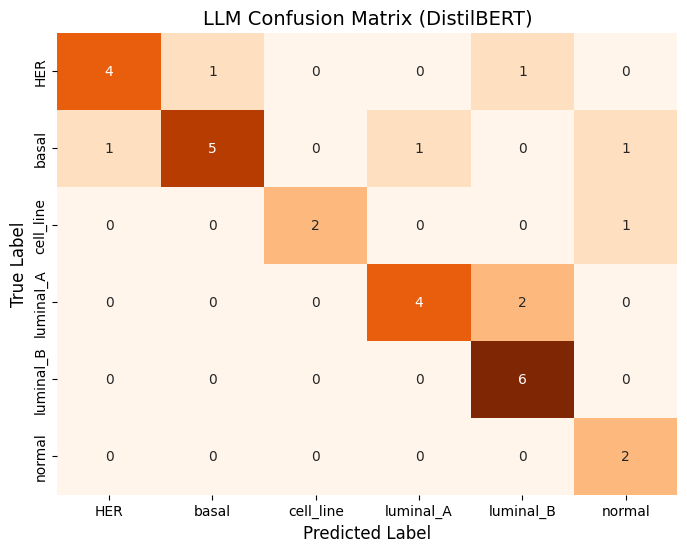

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get Predictions from Trainer
print("Generating LLM predictions...")
predictions = trainer.predict(test_dataset)
y_pred_llm = np.argmax(predictions.predictions, axis=1)

# 2. Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_llm)

# 3. Plot
plt.figure(figsize=(8, 6))
# Using 'Oranges' to distinguish it from the others
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('LLM Confusion Matrix (DistilBERT)', fontsize=14)
plt.show()

✅ LLM Precision & Recall Report:

              precision    recall  f1-score   support

         HER       0.80      0.67      0.73         6
       basal       0.83      0.62      0.71         8
   cell_line       1.00      0.67      0.80         3
   luminal_A       0.80      0.67      0.73         6
   luminal_B       0.67      1.00      0.80         6
      normal       0.50      1.00      0.67         2

    accuracy                           0.74        31
   macro avg       0.77      0.77      0.74        31
weighted avg       0.78      0.74      0.74        31



/tmp/ipython-input-230912905.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


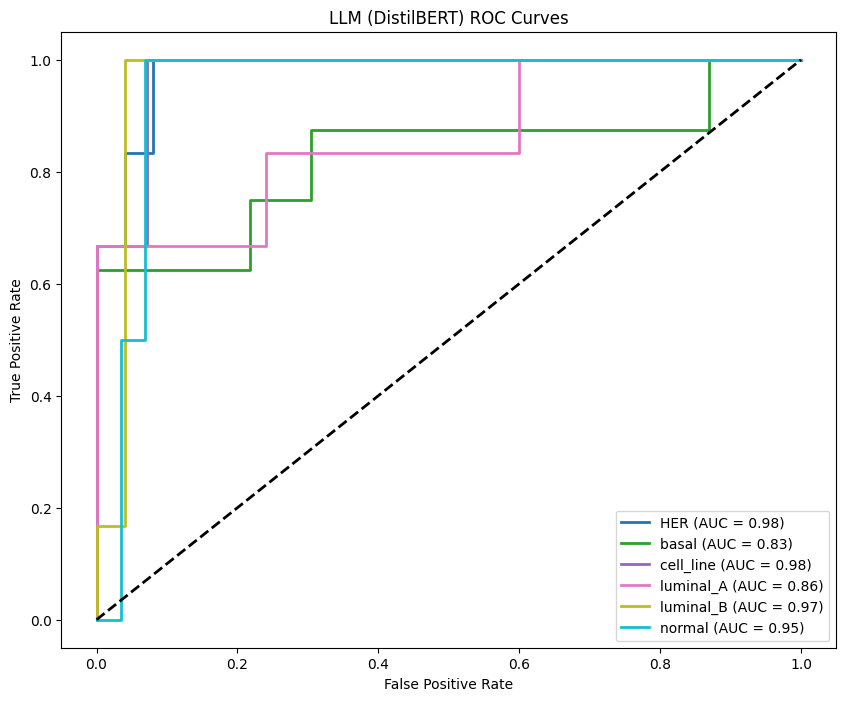

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch

# --- 1. Get Probabilities from Logits ---
predictions = trainer.predict(test_dataset)
logits = torch.tensor(predictions.predictions)
y_probs = F.softmax(logits, dim=1).numpy() # Convert logits to 0-1 probabilities

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]
y_pred_class = np.argmax(y_probs, axis=1)

# --- 2. Print Precision/Recall Values ---
print("✅ LLM Precision & Recall Report:\n")
print(classification_report(y_test, y_pred_class, target_names=le.classes_))

# --- 3. Plot ROC Curve ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LLM (DistilBERT) ROC Curves')
plt.legend(loc="lower right")
plt.show()